In [1]:
import os, pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
from visualizations import flatmap_real_vals 
import seaborn as sns
from scipy.stats import ttest_ind 

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
dataset_name = 'MDTB' # or Demand

projectPath, mainResultsPath = setProjectPath()
resultsPath = os.path.join(mainResultsPath, 'START_A2_gse_decomposition', dataset_name)
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
PKL_output = os.path.join(resultsPath, f'{dataset_name}_output.pkl') 

In [4]:
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

## visualize voxel-wise vs / (vs + vg) for the whole cortex

In [5]:
result = output['whole_cortex']['voxel_wise']   # columns in the order: vg, vs, ve 
voxel_wise_cortex = np.divide(result[:, 1].reshape((-1, 1)), np.sum(result[:, 0:2], axis=1, keepdims=True)) 

findfont: Font family 'helvetica' not found.
findfont: Font family ['helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.


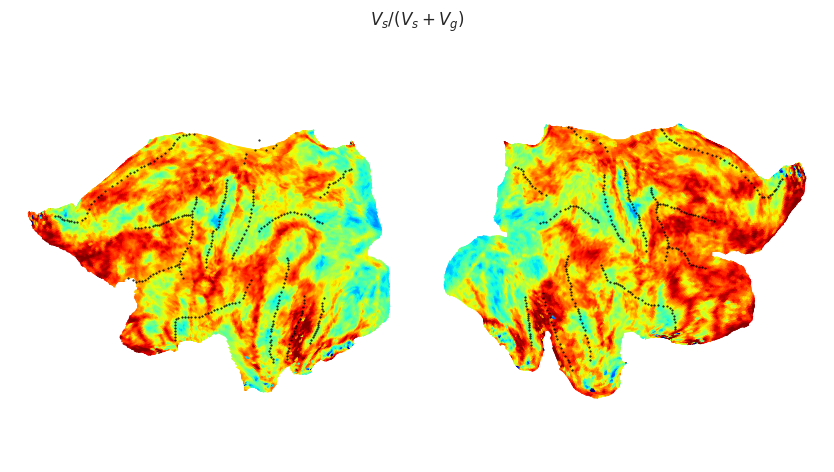

In [6]:
plt.figure().set_figwidth(full_width) 
plt.subplot(1, 2, 1)
flatmap_real_vals(voxel_wise_cortex, hemi='L', cscale=[0, 1], cmap='jet') 
plt.subplot(1, 2, 2)
flatmap_real_vals(voxel_wise_cortex, hemi='R', cscale=[0, 1], cmap='jet', colorbar=False)  
plt.suptitle('$V_s/(V_s+V_g)$', fontsize=12)
plt.tight_layout()

PS_variance = os.path.join(resultsPath, f'{dataset_name}_flatmap_v_s_gs.jpg')
if os.path.exists(PS_variance):
    os.remove(PS_variance)
plt.savefig(PS_variance, format='jpg', dpi=500)

## vs/(vs + vg) in whole cortex, PFC, visual, somatosensory and parietal regions

In [7]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal']
n_rois = len(ROIs)
props = [] 

for roiI in np.arange(n_rois):
    result = np.array(output[ROIs[roiI]]['global'])  
    prop = np.divide(result[:,1], result[:,0]+result[:,1])
    props.append(prop) 

props = np.array(props)     # n_rois x n_bootstraps, each element is vs/(vs+vg) 

In [8]:
props_mean = props[:, 0] 
props_std = np.std(props[:, 1:]) 

findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: 

PFC and visual: 0.0
PFC and somatosensory: 0.0
PFC and parietal: 0.0


findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: 

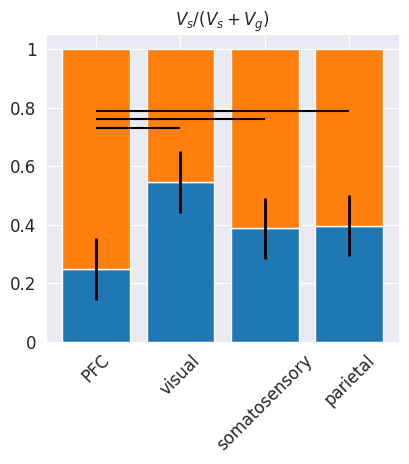

In [9]:
fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width) 

# sns.barplot(props_mean, color='tab:orange', ax=ax)            # bar plot for the mean of vs 
# sns.barplot(props_mean - 1, color='tab:blue', ax=ax)          # bar plot for the mean of vg
bottoms = np.zeros(n_rois) 
plt.bar(np.arange(n_rois), 1 - props_mean, label='group', bottom=bottoms, color='tab:blue') 
bottoms += 1 - props_mean
plt.bar(np.arange(n_rois), props_mean, label='individual', bottom=bottoms, color='tab:orange')  
# plt.legend(frameon=False) 

ax.errorbar(np.arange(n_rois), 1 - props_mean, yerr=props_std, linestyle='None', color='k', linewidth=2) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(n_rois), labels=ROIs, fontsize=12, rotation=45)
ax.set_title('$V_s/(V_s + V_g)$', fontsize=12) 
ax.yaxis.set_major_formatter(lambda x, pos: f'{abs(x):g}')

# bootstrap tests between PFC and other ROIs 
significance_level = 0.05 
for j in np.arange(1, n_rois):
    pvalue = np.sum(props[0, 1:] < props[j, 1:]) / len(props[0, 1:]) 
    if pvalue < significance_level:
        ax.hlines(y = 0.7+j*0.03, xmin=0, xmax=j, colors='0')

    print(f'PFC and {ROIs[j]}: {pvalue}') 

plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'variance_decomposition_bar_plot.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In PFC, group variance accounts for 24% out of total explainable variance, while individual variance accounts for 76%. 